# U.S. Traffic Safety Analysis

**GitHub Repository:** https://github.com/pkroberg/Traffic-Safety-Analysis

---

## Overview

This notebook looks at traffic accident patterns across the United States using two datasets. The goal is to understand how factors like time of day, weather conditions, road features, and vehicle type relate to accident frequency and severity with a particular focus on motorcycle risk.

## Datasets I Used

### 1. US Accidents (Kaggle) — Primary Dataset
- **Source:** https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
- **Coverage:** ~7.7 million accidents across the contiguous US, 2016–2023
- **Contents:** Accident severity, location, time, weather conditions, and road features
- **Note:** This file (~3GB) is too large to include in the repository. Download it from Kaggle and place `US_Accidents_March23.csv` in the same directory as this notebook.

### 2. FARS — Fatality Analysis Reporting System (NHTSA) — Motorcycle Risk Dataset
- **Source:** https://www.nhtsa.gov/file-downloads?p=nhtsa/downloads/FARS/
- **Coverage:** All fatal crashes in the US, 2016–2023
- **Contents:** Crash details including vehicle type, enabling motorcycle-specific fatality analysis
- **Files used:** `FARS{year}NationalCSV.zip` for years 2016–2023 (included in this repository)

## Why the need to merge these datasets?

The Kaggle dataset covers all accident severities but does not include vehicle type. It can't distinguish between car and motorcycle accidents. FARS covers only fatal crashes, but does record vehicle type. Since these datasets measure different things, they cannot be joined row-to-row. Instead, we use FARS to compute motorcycle fatality risk ratios by state and hour of day, then attach those ratios to the Kaggle data. This gives the primary dataset motorcycle-specific risk context without discarding non-fatal accidents.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

years = range(2016, 2024)
fars_list = []

for year in years:
    folder = f'FARS{year}NationalCSV'
    accident = pd.read_csv(os.path.join(folder, 'accident.CSV'), encoding='latin-1', low_memory=False)
    vehicle = pd.read_csv(os.path.join(folder, 'Vehicle.CSV'),encoding='latin-1', low_memory=False)
    accident['year'] = year
    merged = accident.merge(vehicle, on='ST_CASE', how='left').copy()
    fars_list.append(merged)

all_fars = pd.concat(fars_list, ignore_index=True)
print(f'FARS records loaded: {len(all_fars):,}')
print(f'Columns: {all_fars.shape[1]}')

FARS records loaded: 445,189
Columns: 314


### Prep FARS dataset for Merge

FARS encodes states as numeric FIPS codes (e.g. 6 = California), while the Kaggle dataset uses two-letter abbreviations (e.g. `CA`). I mapped FIPS codes to abbreviations so both datasets share a common state representation.

I also flaged each vehicle record as motorcycle or non-motorcycle using FARS body type codes. The motorcycle codes are: 80, 81, 83, 84, 88, 89.

Records with no state assigned are dropped.

In [ ]:
all_fars = all_fars.dropna(subset=['STATE'])

# Map FIPS codes to state abbreviations
fips_to_abbr = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA',
    8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC', 12: 'FL',
    13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN',
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME',
    24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH',
    34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND',
    39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI',
    45: 'SC', 46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT',
    50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI',
    56: 'WY'
}
all_fars['state_abbr'] = all_fars['STATE'].map(fips_to_abbr)

# motorcycle involvement
motorcycle_codes = {80, 81, 83, 84, 88, 89}
all_fars['is_motorcycle'] = all_fars['BODY_TYP'].isin(motorcycle_codes)

print(f'Motorcycle vehicle records: {all_fars["is_motorcycle"].sum():,}')
print(f'Total vehicle records: {len(all_fars):,}')
print(f'Motorcycle share of fatal crashes: {all_fars["is_motorcycle"].mean():.1%}')

Motorcycle vehicle records: 12,424
Total vehicle records: 122,567
Motorcycle share of fatal crashes: 10.1%


/var/folders/_0/zv11xt810z95kdnzw5h_v4h40000gn/T/ipykernel_38566/1143680027.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_fars['state_abbr'] = all_fars['STATE'].map(fips_to_abbr)
/var/folders/_0/zv11xt810z95kdnzw5h_v4h40000gn/T/ipykernel_38566/1143680027.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_fars['is_motorcycle'] = all_fars['BODY_TYP'].isin(motorcycle_codes)


## Loading Kaggle Data

The Kaggle dataset contains ~7.7 million accident records. Since the full file is ~3GB, I only loaded the relevant columns. The chosen columns cover accident severity, location, time, weather, and road features.

In [3]:
kaggle_cols_to_keep = [
    'ID', 'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'City', 'County', 'State', 'Zipcode',
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 
    'Weather_Condition', 'Sunrise_Sunset', 'Junction', 'Traffic_Signal', 'Crossing', 
    'Roundabout', 'Stop',
]

kaggle_df = pd.read_csv('US_Accidents_March23.csv', usecols=kaggle_cols_to_keep)
print(f'Kaggle records loaded: {len(kaggle_df):,}')
kaggle_df.info()

Kaggle records loaded: 7,728,394
<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 21 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ID                 str    
 1   Severity           int64  
 2   Start_Time         str    
 3   Start_Lat          float64
 4   Start_Lng          float64
 5   City               str    
 6   County             str    
 7   State              str    
 8   Zipcode            str    
 9   Temperature(F)     float64
 10  Humidity(%)        float64
 11  Visibility(mi)     float64
 12  Wind_Speed(mph)    float64
 13  Precipitation(in)  float64
 14  Weather_Condition  str    
 15  Crossing           bool   
 16  Junction           bool   
 17  Roundabout         bool   
 18  Stop               bool   
 19  Traffic_Signal     bool   
 20  Sunrise_Sunset     str    
dtypes: bool(5), float64(7), int64(1), str(8)
memory usage: 980.3 MB


### Fixing weird timestamps

The Start_Time column is inconsistent across the records. I used format='mixed' to fix it, then extracted hour, month, and year as separate columns so I can use it in groupby.

In [4]:
kaggle_df['Start_Time'] = pd.to_datetime(kaggle_df['Start_Time'], format='mixed')
kaggle_df['hour'] = kaggle_df['Start_Time'].dt.hour
kaggle_df['month'] = kaggle_df['Start_Time'].dt.month
kaggle_df['year'] = kaggle_df['Start_Time'].dt.year

### Fixing nulls

There are null counts across all columns. Precipitation(in) has a very high amount of nulls because a "null" here means no precipitation, so I filled it with 0.

In [5]:
print('Null count:')
print(kaggle_df.isnull().sum())

# Fill precipitation nulls with 0 (no precipitation recorded = no precipitation)
kaggle_df['Precipitation(in)'] = kaggle_df['Precipitation(in)'].fillna(0)

Null count:
ID                         0
Severity                   0
Start_Time                 0
Start_Lat                  0
Start_Lng                  0
City                     253
County                     0
State                      0
Zipcode                 1915
Temperature(F)        163853
Humidity(%)           174144
Visibility(mi)        177098
Wind_Speed(mph)       571233
Precipitation(in)    2203586
Weather_Condition     173459
Crossing                   0
Junction                   0
Roundabout                 0
Stop                       0
Traffic_Signal             0
Sunrise_Sunset         23246
hour                       0
month                      0
year                       0
dtype: int64


### Severity and Weather Distribution

Distribution of accident severity and the most common weather conditions.

In [6]:
print('Severity distribution:')
print(kaggle_df['Severity'].value_counts().sort_index())

print('\nTop 20 weather conditions:')
print(kaggle_df['Weather_Condition'].value_counts().head(20))

Severity distribution:
Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64

Top 20 weather conditions:
Weather_Condition
Fair                       2560802
Mostly Cloudy              1016195
Cloudy                      817082
Clear                       808743
Partly Cloudy               698972
Overcast                    382866
Light Rain                  352957
Scattered Clouds            204829
Light Snow                  128680
Fog                          99238
Rain                         84331
Haze                         76223
Fair / Windy                 35671
Heavy Rain                   32309
Light Drizzle                22684
Thunder in the Vicinity      17611
Cloudy / Windy               17035
T-Storm                      16810
Mostly Cloudy / Windy        16508
Snow                         15537
Name: count, dtype: int64


## Merge Motorcycle Risk to Kaggle Data

Since FARS and Kaggle can't be joined row to row, I computed motorcycle fatality risk ratios from FARS aggregated by state and hour of day, then attached those ratios to the Kaggle data as new columns. This enriches each accident record with context about how likely a fatal crash in that state and hour involves a motorcycle.

In [7]:
# Compute motorcycle fatality ratio by state + hour from FARS
moto_risk = (
    all_fars[all_fars['HOUR_x'] != 99]
    .groupby(['state_abbr', 'HOUR_x'])['is_motorcycle']
    .mean()
    .reset_index()
    .rename(columns={
        'state_abbr': 'State',
        'HOUR_x': 'hour',
        'is_motorcycle': 'moto_fatality_ratio'
    })
)

# Compute national average by hour as fallback for unmatched rows
national_avg = (
    all_fars[all_fars['HOUR_x'] != 99]
    .groupby('HOUR_x')['is_motorcycle']
    .mean()
    .reset_index()
    .rename(columns={'HOUR_x': 'hour', 'is_motorcycle': 'national_moto_avg'})
)

# Merge state-level ratios onto Kaggle data, fill unmatched with national average
kaggle_df = kaggle_df.merge(moto_risk, on=['State', 'hour'], how='left')
kaggle_df = kaggle_df.merge(national_avg, on='hour', how='left')
kaggle_df['moto_fatality_ratio'] = kaggle_df['moto_fatality_ratio'].fillna(
    kaggle_df['national_moto_avg'])
kaggle_df = kaggle_df.drop(columns=['national_moto_avg'])

print(f'# of rows: {len(kaggle_df):,}')
print(f'Remaining nulls in moto_fatality_ratio: {kaggle_df["moto_fatality_ratio"].isna().sum()}')

# of rows: 7,728,394
Remaining nulls in moto_fatality_ratio: 0


## Analysis

### When Do Accidents Happen?

I started by examining accident frequency by hour of day. This gave me a baseline understanding of when roads are most dangerous.

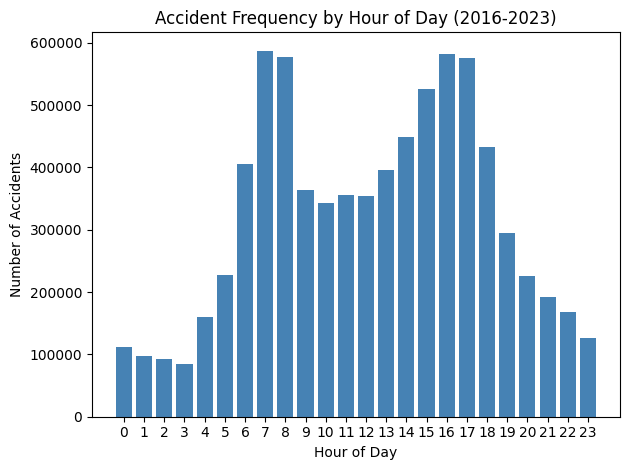

In [9]:
accidents_by_hour = kaggle_df.groupby('hour').size().reset_index(name='accident_count')

fig, ax = plt.subplots()
ax.bar(accidents_by_hour['hour'], accidents_by_hour['accident_count'], color='steelblue')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Accidents')
ax.set_title('Accident Frequency by Hour of Day (2016-2023)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

### How Does Severity Vary by Time of Day?

Accident frequency alone doesn't tell the full story. Here I looked at the average severity of accidents by hour to see whether high volume commute hours are also the most dangerous, or if low-traffic overnight hours produce more severe crashes.

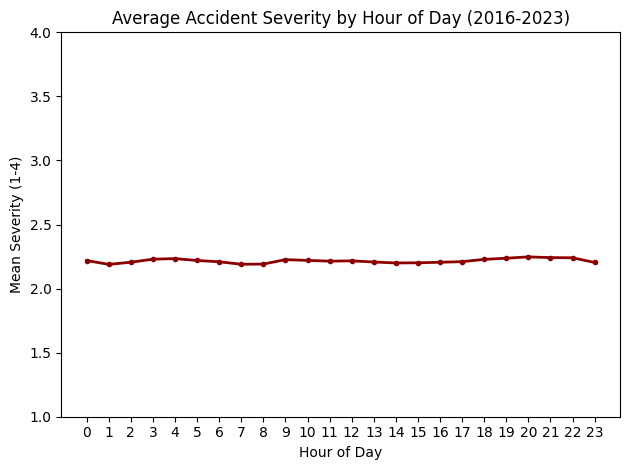

In [18]:
severity_by_hour = kaggle_df.groupby('hour')['Severity'].mean().reset_index()

fig, ax = plt.subplots()
ax.plot(severity_by_hour['hour'], severity_by_hour['Severity'], color='darkred', marker='.', linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Severity (1-4)')
ax.set_title('Average Accident Severity by Hour of Day (2016-2023)')
ax.set_xticks(range(0, 24))
ax.set_ylim(1, 4)
plt.tight_layout()
plt.show()

Because the Kaggle dataset is dominated by level 2, it makes the graph look almost flat.

### Motorcycle Risk by Hour of Day

Using fatality data from FARS, I examined how fatal crashes involving motorcycles change throughout the day. Unlike the Kaggle dataset, FARS records vehicle type, which allowed me to isolate motorcycle-specific risk. A higher ratio means motorcycles represent a greater share of fatal crashes at that hour.

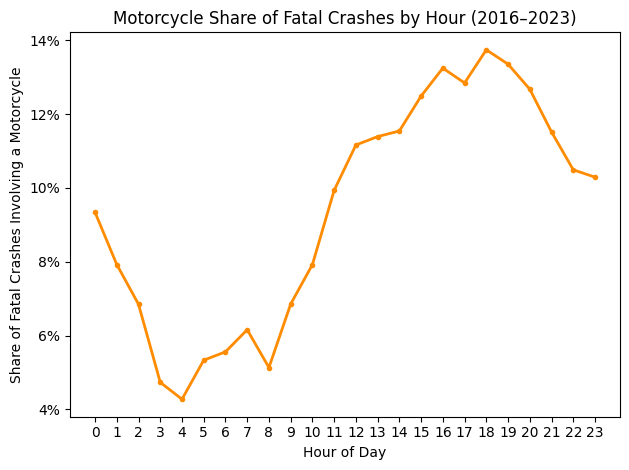

In [20]:
moto_by_hour = (
    all_fars[all_fars['HOUR_x'] != 99]
    .groupby('HOUR_x')['is_motorcycle']
    .mean()
    .reset_index()
    .rename(columns={'HOUR_x': 'hour', 'is_motorcycle': 'moto_fatality_ratio'})
)

fig, ax = plt.subplots()
ax.plot(moto_by_hour['hour'], moto_by_hour['moto_fatality_ratio'], color='darkorange', marker='.', linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Share of Fatal Crashes Involving a Motorcycle')
ax.set_title('Motorcycle Share of Fatal Crashes by Hour (2016–2023)')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

Looks like the peak is ~2-6pm when recreational riding is most common, and dips overnight and during the morning commute.

### How Does Weather Affect Accident Severity?

I put the raw weather conditions into broader categories and looked at how average severity differs across them. This showed if bad weather conditions produces more serious accidents, or if good weather driving carries its own risks.

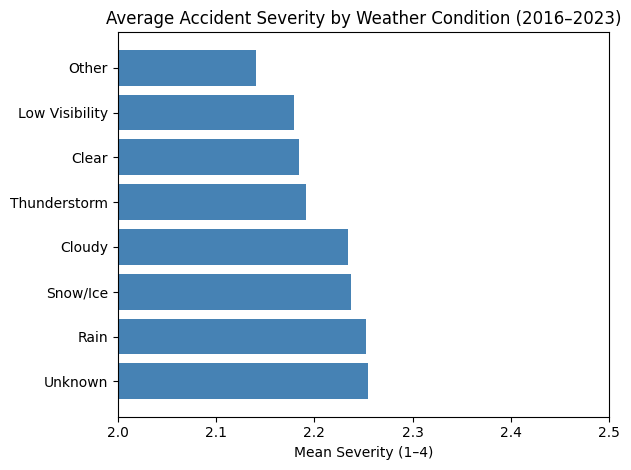

In [ ]:
def bucket_weather(condition):
    if pd.isna(condition):
        return 'Unknown'
    c = condition.lower()
    if any(x in c for x in ['snow', 'sleet', 'ice', 'wintry', 'blizzard', 'freezing']):
        return 'Snow/Ice'
    if any(x in c for x in ['rain', 'drizzle', 'shower']):
        return 'Rain'
    if any(x in c for x in ['thunder', 't-storm', 'squall']):
        return 'Thunderstorm'
    if any(x in c for x in ['fog', 'mist', 'haze', 'smoke', 'dust', 'sand']):
        return 'Low Visibility'
    if any(x in c for x in ['clear', 'fair']):
        return 'Clear'
    if any(x in c for x in ['cloud', 'overcast', 'scattered']):
        return 'Cloudy'
    return 'Other'


kaggle_df['Weather_Bucket'] = kaggle_df['Weather_Condition'].apply(bucket_weather)

weather_severity = (
    kaggle_df.groupby('Weather_Bucket')['Severity']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_severity', 'count': 'accident_count'})
    .sort_values('avg_severity', ascending=False)
)

fig, ax = plt.subplots()
ax.barh(weather_severity['Weather_Bucket'], weather_severity['avg_severity'], color='steelblue')
ax.set_xlabel('Mean Severity (1-4)')
ax.set_title('Average Accident Severity by Weather Condition (2016-2023)')
ax.set_xlim(2, 2.5)
plt.tight_layout()
plt.show()

The severity goes from 1 to 4, but the graph is zoomed in due to the values being so close.

### Motorcycle Risk by State

I aggregated the motorcycle fatality ratio by state to identify which states have the highest proportion of fatal crashes involving motorcycles. Geographic variation in motorcycle risk reflects differences in riding culture, road infrastructure,
helmet laws, and climate.

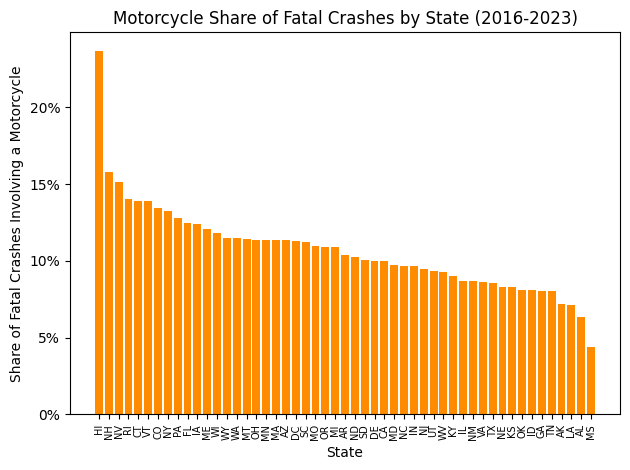

   state  moto_fatality_ratio
11    HI             0.237113
30    NH             0.158192
33    NV             0.151253
39    RI             0.140244
6     CT             0.138801
46    VT             0.138756
5     CO             0.134406
34    NY             0.132358
38    PA             0.128235
9     FL             0.124568


In [28]:
moto_by_state = (
    all_fars[all_fars['HOUR_x'] != 99]
    .groupby('state_abbr')['is_motorcycle']
    .mean()
    .reset_index()
    .rename(columns={'state_abbr': 'state', 'is_motorcycle': 'moto_fatality_ratio'})
    .sort_values('moto_fatality_ratio', ascending=False)
)

fig, ax = plt.subplots()
ax.bar(moto_by_state['state'], moto_by_state['moto_fatality_ratio'], color='darkorange')
ax.set_xlabel('State')
ax.set_ylabel('Share of Fatal Crashes Involving a Motorcycle')
ax.set_title('Motorcycle Share of Fatal Crashes by State (2016-2023)')
ax.tick_params(axis='x', labelsize=7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(moto_by_state.head(10))

Hawaii has a disproportionate amount of motorcycle fatalaties compared to the rest of the US.

## Conclusion

This report combined two complementary datasets, a 7.7 million accident record from the Kaggle US Accidents dataset and 8 years of fatal crash data from NHTSA FARS to examine when, where, and under what conditions traffic accidents are most dangerous
in the United States. </br>
Several limitations should be noted. The Kaggle dataset excludes Alaska and has uneven state coverage. FARS covers only fatal crashes, so motorcycle risk ratios derived from it reflect fatal outcomes specifically rather than all accident types. Severity in the Kaggle dataset is heavily skewed toward level 2, limiting the usefulness of mean severity as a metric.